# Process List of NaI Background Data Files

This notebook develops and tests a function to process a list of HDF5 files that contains NaI data taken underground in Kamioka.

File comes in a few categories:
1. configuration (top, bottom, east, west, north, south, int)
2. runtype (background or calibration)

Therefore, **the top level is a string that describes the run type and configuration**. 

It will be named as **RunConfiguration-RunType**.
- Run configuration is either of the following
    - top, bottom, east, west, north, south, int
- Run type is one of the following
    - bkg, cal_source_name_-A (e.g. cal_cs_137)

Under each run type and configuration, each file corresponding to each hour will be indexed by the file number.

In [1]:
import pyradet.h5util.h5reader as h5reader
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import re
import glob

In [2]:
timestamp_kamioka = 1742871600
# timestamp of 12pm, 2025-03-25

## Function to Manipulate Text Files

Use regular expression to inspect the file name.

In [3]:
def extract_run_number(filename: str) -> int:
    """
    Given the filename, return the run number.
    This run number will be used as file index.
    """
    match = re.search(r"Run(\d+)", filename)
    if match:
        return int(match.group(1))
    else:
        raise ValueError("Run number not found in filename.")

def parse_filename(filename: str):
    """
    Given NaI background/calibration files in hdf5 format, named according to the following convention:
        NaI_Background/Calibration_Direction(_SourceAA)_RunXXX_YYYYMMDD_HHMMSS.hdf5
    where SourceAA is true only for the case of calibration
    This function returns the key to be associated with this file
    """
    
    run_number = extract_run_number(filename)
    
    # Match background: NaI_Background_<position>_...
    bg_pattern = r"NaI_Background_(top|bottom|east|west|south|north|int)_"
    bg_match = re.search(bg_pattern, filename, re.IGNORECASE)
    
    if bg_match:
        position = bg_match.group(1).lower()
        return f"{position}-bkg", run_number

    # Match calibration: NaI_Calibration_<position>_<isotope><mass>_...
    cal_pattern = r"NaI_Calibration_(top|bottom|east|west|south|north|int)_([A-Za-z]{1,2}\d{2,3})_"
    cal_match = re.search(cal_pattern, filename, re.IGNORECASE)
    if cal_match:
        position = cal_match.group(1).lower()
        source = cal_match.group(2)
        return f"{position}-cal-{source}", run_number

    # If neither matched
    raise ValueError(f"Filename does not match expected pattern: {filename}")

def find_file_by_run_id(run_id, position, directory="."):
    # Capitalize the first character of the position
    position = position.capitalize()

    # Define the glob pattern using the capitalized position and run ID
    pattern = f"{directory}/NaI_*_{position}*Run{run_id}_*.hdf5"
    
    # Find matching files
    matches = glob.glob(pattern)
    
    # Return the matches (or the first match if you expect only one)
    return matches  # or return matches[0] if you expect exactly one file

from collections import defaultdict

def generate_file_dict( filelist ):
    """
        Returns a dictionary where key is description of filetype and value is a list of files belonging to the same type/configuration
    """
    ret = defaultdict(list)
    for file in filelist:
        config, runID = parse_filename( file )
        ret[config].append( file )
    return ret

## Given a text file, generate a list of files to be processed

In [4]:
def read_file_list(filename):
    """
    Reads a text file and returns a list of lines (file paths).
    Strips newlines and skips empty lines.
    """
    try:
        with open(filename, 'r') as file:
            file_list = [line.strip() for line in file if line.strip()]
        return file_list
    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return []
        
listdir = './'
tmp = 'list_all.txt'

datafiles = read_file_list( listdir + tmp )
keys = [ parse_filename(i)[0] for i in datafiles ]
file_dict = generate_file_dict( datafiles )

#print( datafiles )
#print( keys )

# print only up to two files
for i,j in file_dict.items():
    print( i )
    print( file_dict[i][:2])

bottom-bkg
['NaI_Background_Bottom_Run0_HV800_20250325_110531.hdf5', 'NaI_Background_Bottom_Run1_HV800_20250325_120615.hdf5']
east-bkg
['NaI_Background_East_Run0_HV800_20250402_124156.hdf5', 'NaI_Background_East_Run1_HV800_20250402_134239.hdf5']
int-bkg
['NaI_Background_Int_Run0_HV800_20250407_124840.hdf5', 'NaI_Background_Int_Run1_HV800_20250407_134922.hdf5']
north-bkg
['NaI_Background_North_Run0_HV800_20250404_143534.hdf5', 'NaI_Background_North_Run1_HV800_20250404_153617.hdf5']
south-bkg
['NaI_Background_South_Run0_HV800_20250331_125448.hdf5', 'NaI_Background_South_Run1_HV800_20250331_135532.hdf5']
top-bkg
['NaI_Background_Top_Run0_HV800_20250326_115040.hdf5', 'NaI_Background_Top_Run1_HV800_20250326_125123.hdf5']
west-bkg
['NaI_Background_West_Run0_HV800_20250328_121841.hdf5', 'NaI_Background_West_Run1_HV800_20250328_131925.hdf5']


---

---

## Master Function to Process Entire File

The output of this function is an **event matrix** containing reduced quantities of interest for analysis.

In [16]:
def ProcessFile( filenames ):
    """
    Processes specified file and return a matrix corresponding to the reduced quantities of events in the file
    """
    if isinstance(filenames, str):
        filenames = [filenames]
    
    channel = 0
    pre_trig_subtract = 10
    
    event_stat = []
        # result will be array of python tuples
    
    for filename in filenames:
        print( filename )

        run_number = extract_run_number( filename )
    
        reader = h5reader.DataReader( filename )
        reader.Open()

        adc_attr = reader.GetADCAttributes()
    
        pre_trigger_window = adc_attr['nb_pre_trigger_sample']
        threshold = adc_attr['channel_threshold']

        counter = 0

        for event_data, event_attr in reader.GetEventIterator():
    
            print( "- processing event {}".format(event_attr["index"]), end='\r' )

            array = event_data[channel]

            mean, dev = GetBaseline( array, pre_trigger_window )

            tmp4 = np.max( array )
                # maximum ADC count in the entire waveform
            tmp5 = np.min( array )
                # minimum ADC count in the entire waveform

            tmp6 = len( array[ array > (tmp4+tmp5)/2 ] ) / len(array)
                # fraction of waveform above the middle of the range
    
            # Now perform baseline subtraction and get energy information
            #        
            array_rev =  mean * np.ones( len(array) ) - array
                # use the entire array to calculate mean and fluctuation
    
            begin = GetPulseBegin( array_rev, pre_trigger_window, 1 )
    
            tmp = array_rev[ begin - 4 : begin + 500 ]
            energy1 = np.trapezoid(tmp) * 0.004
            height1 = np.max(tmp)
    
            tmp2 = array_rev[ begin + 500 : ]
            energy2 = np.trapezoid(tmp2) * 0.004
            height2 = np.max(tmp2)

            event_stat.append( [run_number,counter,mean,dev,tmp4,tmp5,tmp6,height1,energy1,height2,energy2,event_attr['timestamp']] )

            counter += 1
        
        reader.Close()
    
    print('')

    return np.array(event_stat)


def calculate_run_time( filenames ):
    """
    Calculates the runtime by subtracting the begin time from end time in Linux timestamp.
    """
    if isinstance(filenames, str):
        filenames = [filenames]

    output = []
    begin = []
    end = []

    for f in filenames:
        
        reader = h5reader.DataReader( f )
        reader.Open()
        
        tmp1 = reader.GetAttributes()['timestamp']
        tmp2 = reader.GetAttributes()['timestamp_end']
        
        output.append( tmp2 - tmp1 )
        begin.append( tmp1 )
        end.append( tmp2 )
        reader.Close()

    return output, begin, end


def get_timestamps( filenames ):
    """
    Calculates the runtime by subtracting the begin time from end time in Linux timestamp.
    """
    if isinstance(filenames, str):
        filenames = [filenames]

    output = []
    begin = []
    end = []

    for f in filenames:
        
        reader = h5reader.DataReader( f )
        reader.Open()
        
        tmp1 = reader.GetAttributes()['timestamp']
        tmp2 = reader.GetAttributes()['timestamp_end']
        
        output.append( f )
        begin.append( tmp1 )
        end.append( tmp2 )
        reader.Close()

    return list(zip(begin, end, output))

--- 

# Energy Spectra

For each key (run type), process list of data files and generate an event matrix for all the runs.

In [17]:
filedir = 'data/20250325_NaI_Kamioka/'

event_dictionary = {}
runtime_dictionary = {}
timestamp_dictionary = {}

event_dictionary = np.load( filedir + 'bkg.npz')

for i,j in file_dict.items():
    
    tmp_list = [ filedir + k for k in j ]
    runtime_dictionary[i] = np.sum( calculate_run_time(tmp_list) )
    timestamp_dictionary[i] = get_timestamps( tmp_list )
    
    #event_matrix = ProcessFile( tmp_list )
    #event_dictionary[i] = event_matrix

#np.savez('data/20250325_NaI_Kamioka/bkg.npz', **event_dictionary)
timestamp_list = [item for sublist in timestamp_dictionary.values() for item in sublist]

---

## Make a preliminary plot of energy spectra

In [8]:
std_threshold = 5
max_limit = 4035
frac_above_middle = 0.9

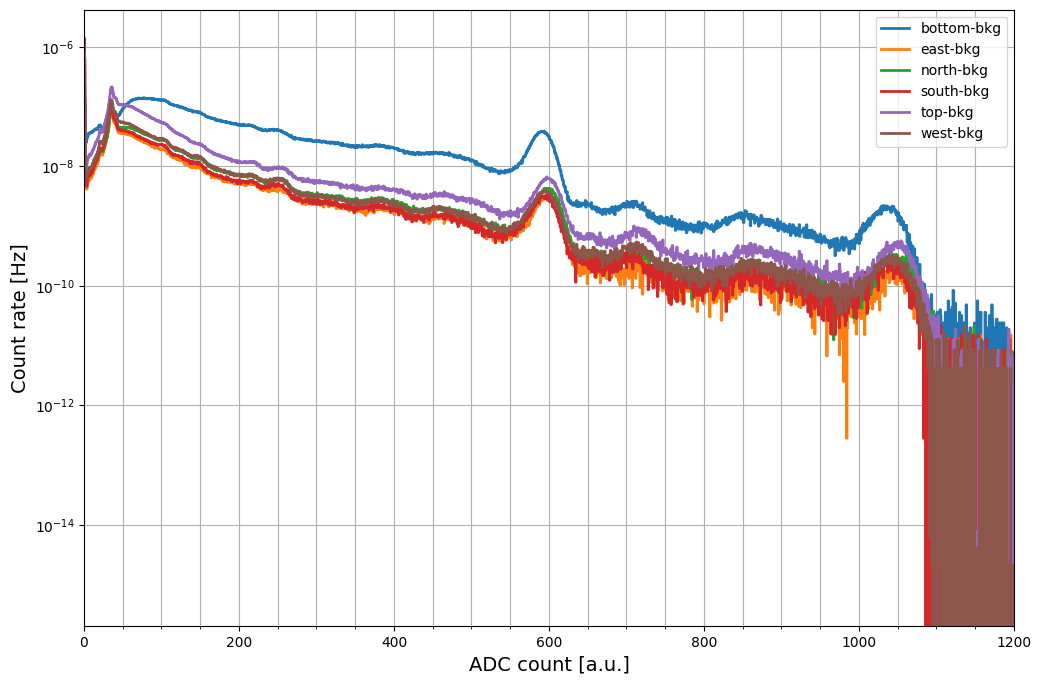

In [21]:
plt.figure( figsize=(12,8) )

event_matrix = event_dictionary['int-bkg']

cut_noise = (event_matrix[:,4] < max_limit) & (event_matrix[:,6] > frac_above_middle) & (event_matrix[:,3] < std_threshold) 
cut_amp = event_matrix[:,7] < 3500
cuts = cut_noise & cut_amp

counts_int, bin_edges = np.histogram( event_matrix[cuts][:,8], bins=2000 )
counts_int = counts_int / runtime_dictionary['int-bkg']

for key, event_matrix in event_dictionary.items():

    #counts1, bin_edges = np.histogram( event_matrix[:,8], bins=1000 );
    #plt.step(bin_edges[:-1], counts1, where='mid', linewidth=2)

    if key == 'int-bkg':
        continue
        
    cut_noise = (event_matrix[:,4] < max_limit) & (event_matrix[:,6] > frac_above_middle) & (event_matrix[:,3] < std_threshold) 
    cut_amp = event_matrix[:,7] < 3500
    cuts = cut_noise & cut_amp
    
    counts2, _= np.histogram( event_matrix[cuts][:,8], bins=bin_edges );
    plt.step(bin_edges[:-1], counts2 / runtime_dictionary[key] - counts_int, where='mid', linewidth=2, label=key )

plt.yscale('log')
plt.xlim([0,1200])

plt.minorticks_on()
plt.grid( which='both')

plt.xlabel('ADC count [a.u.]', fontsize=14)
plt.ylabel('Count rate [Hz]', fontsize=14)

plt.legend()
plt.show()

---

## Baseline Stability

In this section, we will make scatter plots (2D histogram) of mean and standard deviation of baseline over time

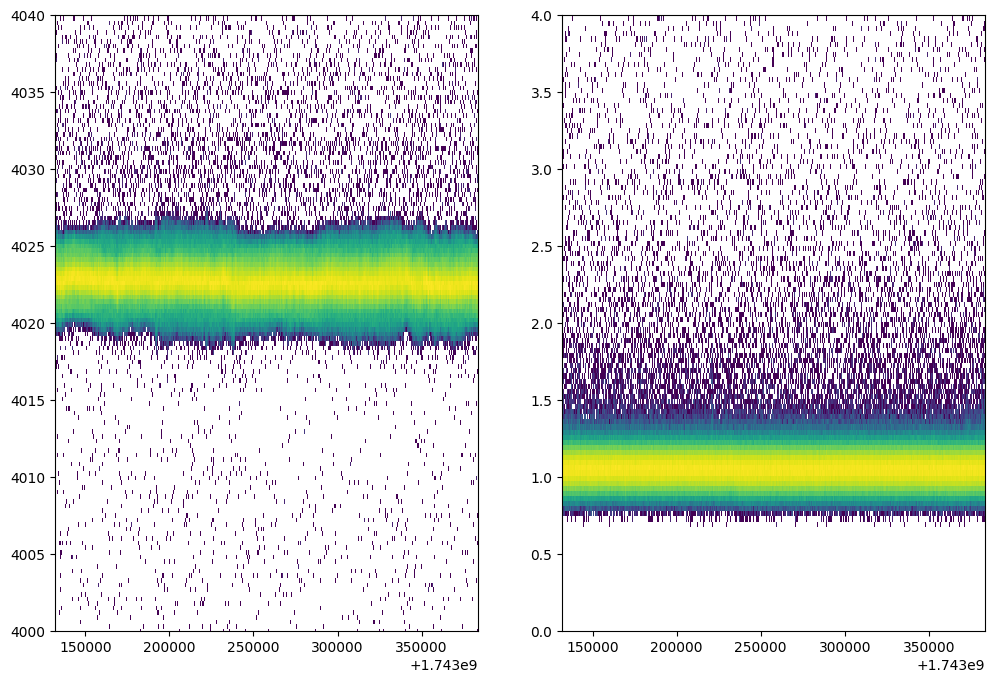

In [11]:
fig, ax = plt.subplots( 1, 2, figsize=(12,8) )

for key, event_matrix in event_dictionary.items():

    ax[0].hist2d( event_matrix[:,11], event_matrix[:,2], bins=(500,500), norm=matplotlib.colors.LogNorm())
    ax[1].hist2d( event_matrix[:,11], event_matrix[:,3], bins=(500,2000), norm=matplotlib.colors.LogNorm())

ax[0].set_ylim([4000,4040])
ax[1].set_ylim([0,4])
plt.show()

## Distribution of Noise Over Time

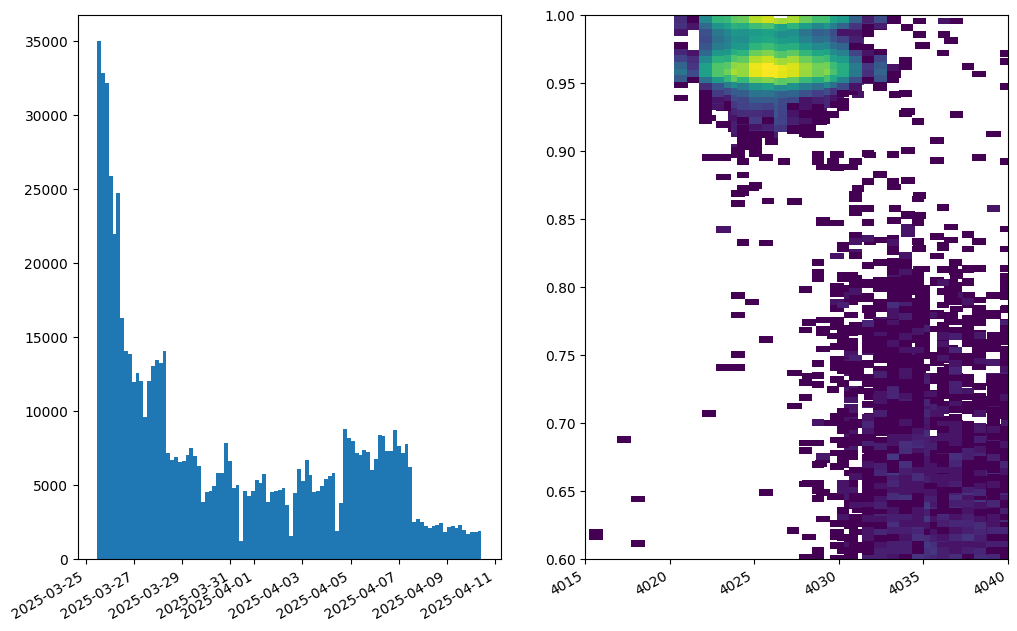

In [12]:
import datetime
import matplotlib.dates as mdates

fig, ax = plt.subplots( 1, 2, figsize=(12,8) )

noise_ts = []

for key, event_matrix in event_dictionary.items():

    mask_noise = (event_matrix[:,4] > 4028) | (event_matrix[:,6] < 0.91)
    dates = [datetime.datetime.fromtimestamp(ts) for ts in event_matrix[mask_noise][:,11] ]
    noise_ts.extend( dates )

    ax[1].hist2d( event_matrix[:,4], event_matrix[:,6], bins=(100,200), norm=matplotlib.colors.LogNorm())

ax[0].hist( noise_ts, bins=100 )
ax[1].set_xlim([4015,4040])
ax[1].set_ylim([0.6,1])

fig.autofmt_xdate()
plt.show()

## Based on the types of noise

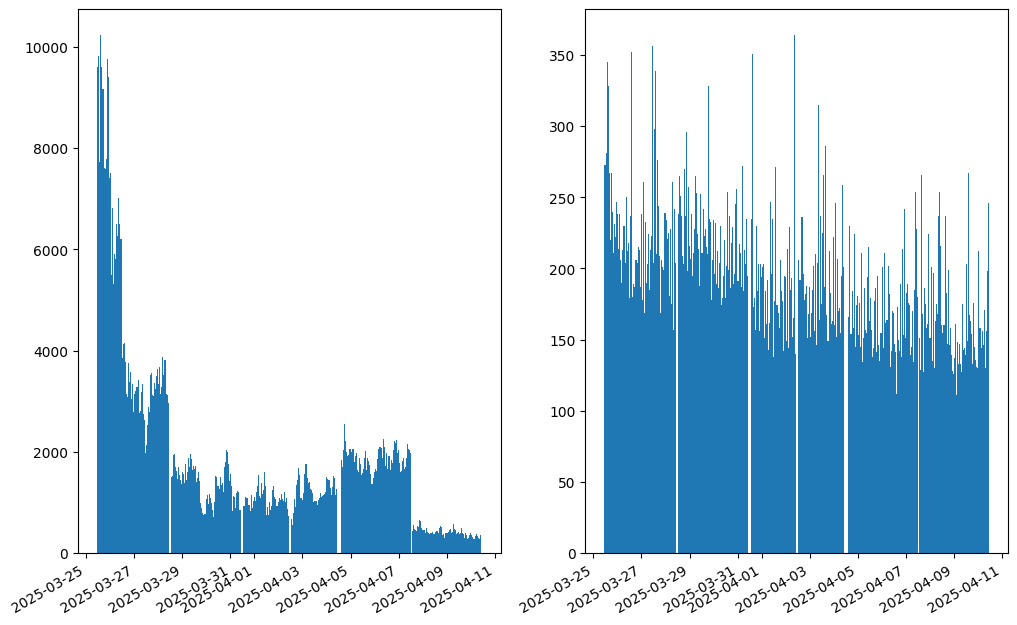

In [55]:
import datetime
import matplotlib.dates as mdates

fig, ax = plt.subplots( 1, 2, figsize=(12,8) )

noise1_ts = []
noise2_ts = []

bin_edges = []

interval = 60 * 60 # binsize is 30 minutes

for key, event_matrix in event_dictionary.items():

    #if key != 'none':
    #    continue

    mask_trans = ( (event_matrix[:,4] > 4028) | (event_matrix[:,6] < 0.91) ) & (event_matrix[:,3] < 1.7)
    mask_osci = ( (event_matrix[:,4] > 4028) | (event_matrix[:,6] < 0.91) ) & (event_matrix[:,3] > 1.7)
    
    dates = [datetime.datetime.fromtimestamp(ts) for ts in event_matrix[:,11] ]
    dates1 = [datetime.datetime.fromtimestamp(ts) for ts in event_matrix[mask_trans][:,11] ]
    dates2 = [datetime.datetime.fromtimestamp(ts) for ts in event_matrix[mask_osci][:,11] ]

    min_date = np.min(dates)
    max_date = np.max(dates)
    
    noise1_ts.extend( dates1 )
    noise2_ts.extend( dates2 )

    start = np.min(event_matrix[:,11])
    stop = np.max(event_matrix[:,11])
    duration = ( stop - start ) / interval

    bin_edges.extend( np.linspace(min_date, max_date, int(duration)) )

bin_edges = np.sort(bin_edges)

ax[0].hist( noise1_ts, bins=bin_edges )
ax[1].hist( noise2_ts, bins=bin_edges )

fig.autofmt_xdate()
plt.show()

## Rate Over Time for SPE-like Pulse

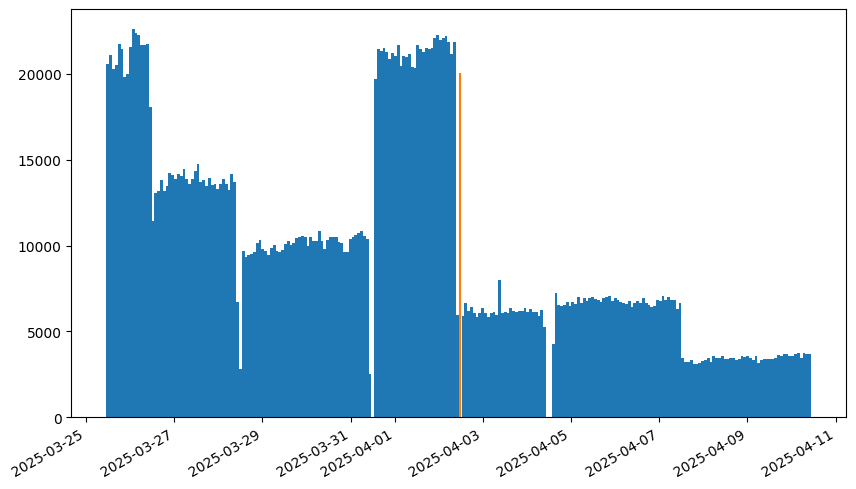

In [14]:
import datetime
import matplotlib.dates as mdates

fig = plt.figure( figsize=(10,6) )

spe_ts = []

for key, event_matrix in event_dictionary.items():

    mask_spe = ( (event_matrix[:,4] < 4028) & (event_matrix[:,6] > 0.98) ) & (event_matrix[:,3] < 2)
    
    dates = [datetime.datetime.fromtimestamp(ts) for ts in event_matrix[mask_spe][:,11] ]
    
    spe_ts.extend( dates )

plt.hist( spe_ts, bins=250 )

lightoff  = datetime.datetime.fromtimestamp(1743561267)
plt.plot( [lightoff, lightoff],[0,20000])

fig.autofmt_xdate()
plt.show()

# Investigate Waveforms in Different Regions in Height-Energy Plane

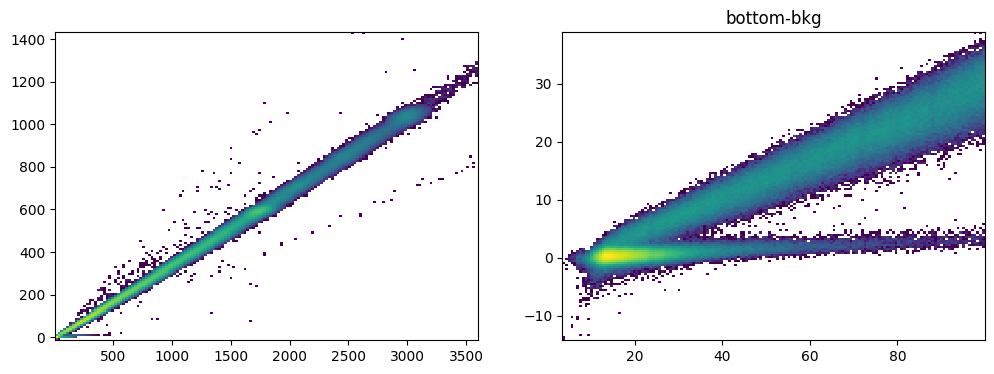

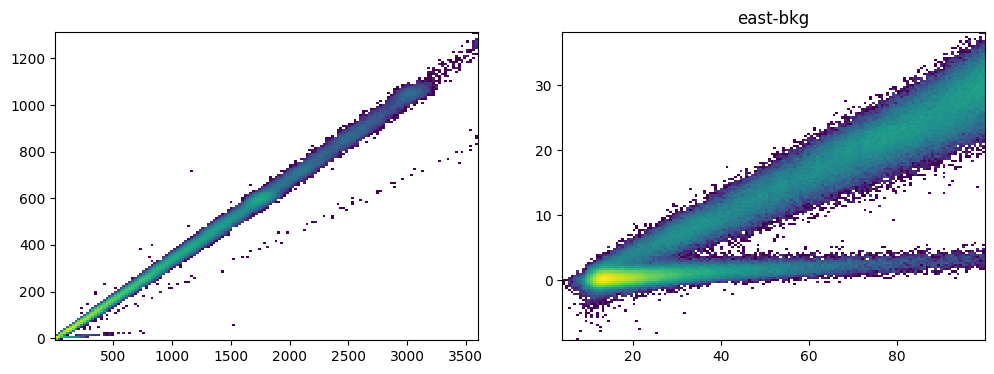

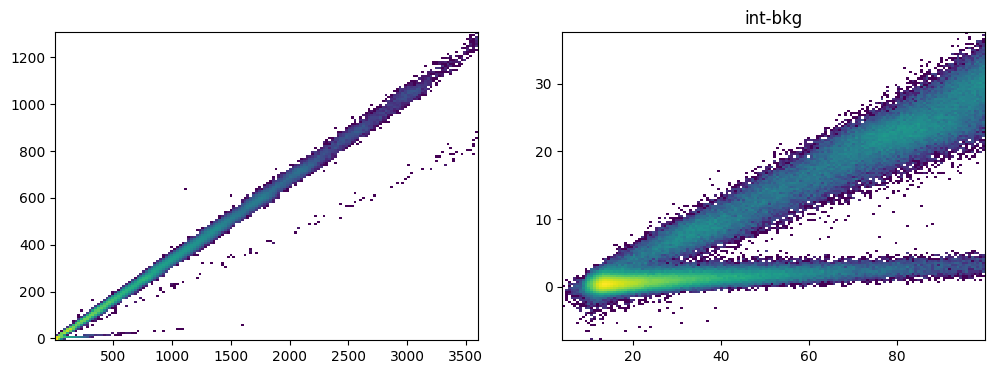

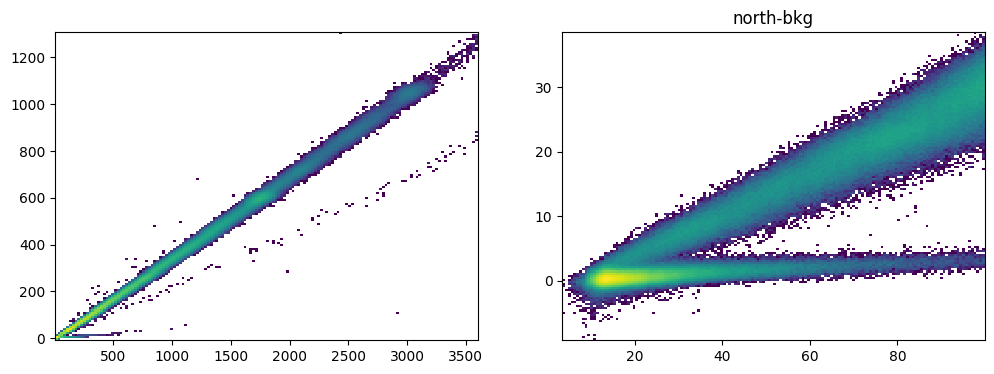

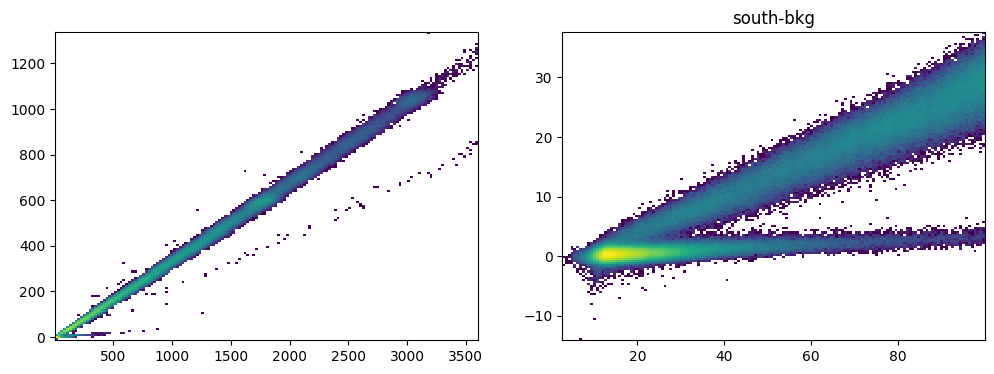

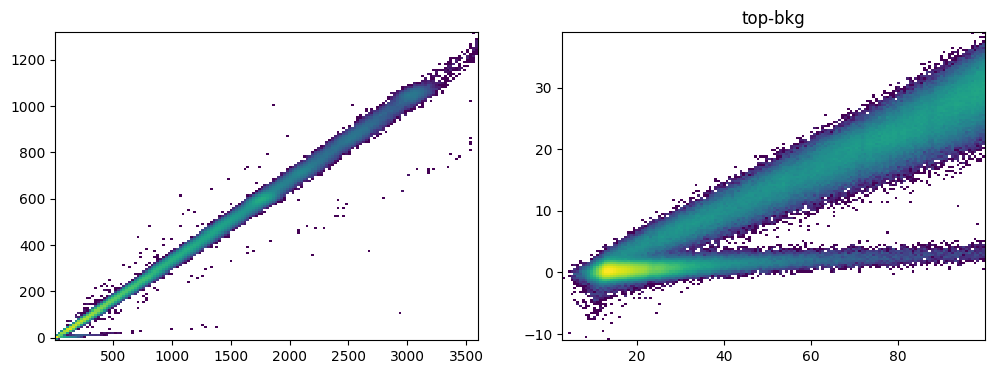

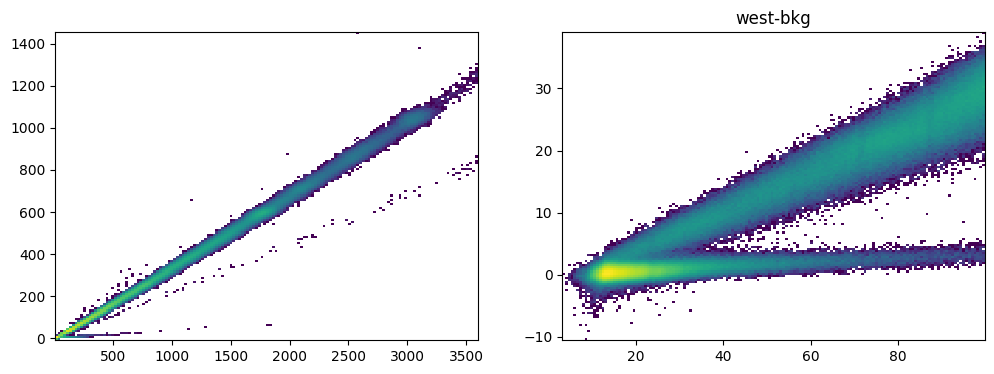

In [15]:
for key, event_matrix in event_dictionary.items():
    
    fig, ax = plt.subplots( 1, 2, figsize=(12,4))
    
    cut_signal = (event_matrix[:,4] < max_limit) & (event_matrix[:,6] > frac_above_middle) & (event_matrix[:,3] < std_threshold)

    cut_range = event_matrix[:,7] < 3600
    ax[0].hist2d( event_matrix[:,7][cut_signal & cut_range], event_matrix[:,8][cut_signal & cut_range], 
                 bins=(150,150), norm=matplotlib.colors.LogNorm())
    
    cut_range = event_matrix[:,7] < 100
    ax[1].hist2d( event_matrix[:,7][cut_signal & cut_range], event_matrix[:,8][cut_signal & cut_range], 
                 bins=(150,150), norm=matplotlib.colors.LogNorm())
    #ax[1].set_xlim( [0,100] )

    plt.title( key )
    plt.show()

---

## All Configurations Added Together

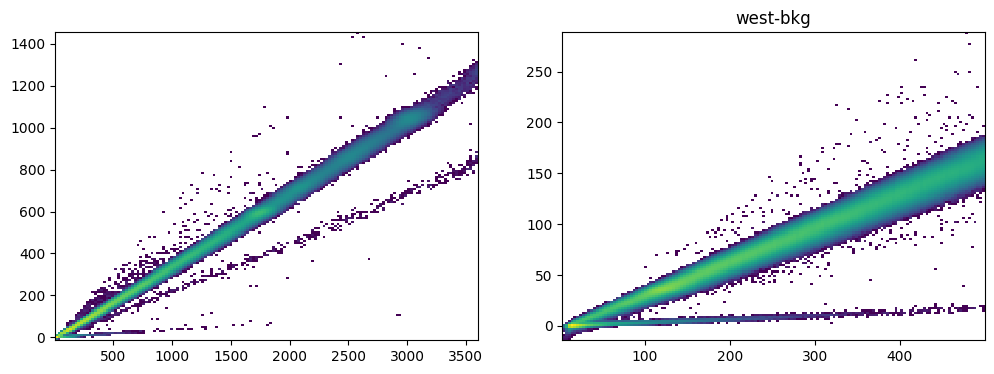

In [22]:
event_all = np.concatenate( list(event_dictionary.values()) )

fig, ax = plt.subplots( 1, 2, figsize=(12,4))
    
cut_signal = (event_all[:,4] < max_limit) & (event_all[:,6] > frac_above_middle) & (event_all[:,3] < std_threshold)

cut_range = event_all[:,7] < 3600
ax[0].hist2d( event_all[:,7][cut_signal & cut_range], event_all[:,8][cut_signal & cut_range], bins=(150,150), norm=matplotlib.colors.LogNorm())
    
cut_range = event_all[:,7] < 500
ax[1].hist2d( event_all[:,7][cut_signal & cut_range], event_all[:,8][cut_signal & cut_range], bins=(150,150), norm=matplotlib.colors.LogNorm())

plt.title( key )
plt.show()

## Region Above the Main Band

Use height = 500 ADC counts as the boundary between high-energy and low-energy

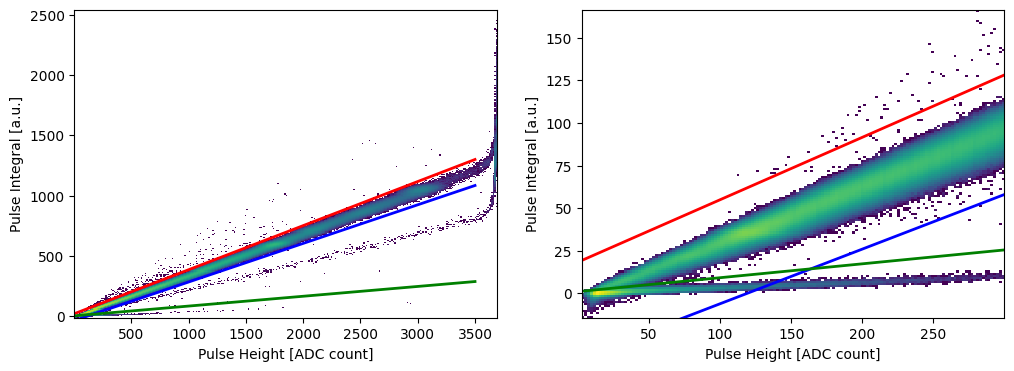

In [187]:
fig, ax = plt.subplots( 1, 2, figsize=(12,4))

cut_noise = (event_all[:,4] < max_limit) & (event_all[:,6] > frac_above_middle) & (event_all[:,3] < std_threshold)

def PileUp( x ):
    x1, x2 = [100,3500]
    y1, y2 = [55,1300]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)
    
def Cut_PileUp( x, y ):
    return y - PileUp(x) < 0

def Alpha( x ):
    x1, x2 = [150,3550]
    y1, y2 = [10,1100]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)
    
def Cut_Alpha( x, y ):
    return y - Alpha(x) > 0

def SPE( x ):
    x1, x2 = [60,600]
    y1, y2 = [6,50]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)
    
def Cut_SPE( x, y ):
    return y - SPE(x) > 0
    
xrange = np.array([0, 300])
xrange_all = np.array([0, 3500])

for i in [0,1]:
    ax[i].plot( xrange_all, PileUp(xrange_all), color = 'red', lw = 2 )
    ax[i].plot( xrange_all, Alpha(xrange_all), color = 'blue', lw = 2 )
    ax[i].plot( xrange_all, SPE(xrange_all), color = 'green', lw = 2 )
    ax[i].set_xlabel( 'Pulse Height [ADC count]' )
    ax[i].set_ylabel( 'Pulse Integral [a.u.]' )


ax[0].hist2d( event_all[:,7][cut_noise], event_all[:,8][cut_noise], bins=(300,300), norm=matplotlib.colors.LogNorm())
    
cut_range = (event_all[:,7] > xrange[0] ) & ( event_all[:,7] < xrange[1] )
ax[1].hist2d( event_all[:,7][cut_noise & cut_range], event_all[:,8][cut_noise & cut_range], bins=(150,150), norm=matplotlib.colors.LogNorm())
plt.show()

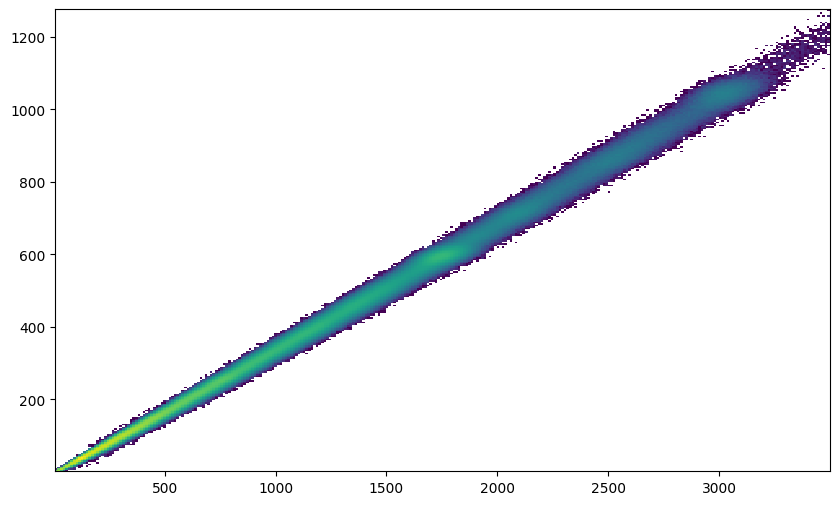

In [40]:
plt.figure( figsize=(10,6) )

cut_noise = (event_all[:,4] < max_limit) & (event_all[:,6] > frac_above_middle) & (event_all[:,3] < std_threshold)
cut_range = (event_all[:,7] > 0) & (event_all[:,7] < 3500)

cuts = cut_noise & cut_range & \
    Cut_PileUp(event_all[:,7],event_all[:,8]) & \
    Cut_Alpha(event_all[:,7],event_all[:,8]) & \
    Cut_SPE(event_all[:,7],event_all[:,8])

for i in [0,1]:
    ax[i].plot( xrange_all, PileUp(xrange_all), color = 'red', lw = 2 )
    ax[i].plot( xrange_all, Alpha(xrange_all), color = 'blue', lw = 2 )
    ax[i].plot( xrange_all, SPE(xrange_all), color = 'green', lw = 2 )
    ax[i].xlabel( 'Pulse Height [ADC count]' )
    ax[i].ylabel( 'Pulse Integral [a.u.]' )

plt.hist2d( event_all[:,7][cuts], event_all[:,8][cuts], bins=(300,300), norm=matplotlib.colors.LogNorm())
plt.show()

---

## Plot Events Lying Outside the Band

## Negative energy events

In [54]:
def find_filename_by_timestamp(ts, file_list):
    """
    Given a timestamp and a list of (filename, start, end) tuples,
    return the filename where start <= ts <= end.
    """
    for start, end, filename in file_list:
        if start <= ts <= end:
            return filename
    return None  # if no match found


def plot_waveform(index, channel, reader):
    """
    Function to make a plot of waveform for a given event (by index)
    """
    index = int(index)
    close_at_end = False
    if isinstance( reader, str ):
        filename = reader.split('/')[-1]
        reader = h5reader.DataReader( reader )
        reader.Open()
        close_at_end = True
        
    plt.figure()
    
    event, event_attr = reader.GetEvent( int(index) )
    adc_attr = reader.GetADCAttributes()
    
    pre_trigger_window = adc_attr['nb_pre_trigger_sample']
    threshold = adc_attr['channel_threshold']
    pre_trig_subtract = 10
    
    if close_at_end:
        reader.Close()
        
    plt.plot( event[channel], label='event {:d}'.format(index) )
    plt.plot( event[channel][:pre_trigger_window-pre_trig_subtract], label='pre-trigger - {}'.format(pre_trig_subtract) )
    plt.xlabel("Time Index")
    plt.ylabel("Amplitude [ADC count]")
    plt.grid(True)
    plt.legend()
    if close_at_end:
        plt.title(filename)
    plt.show()

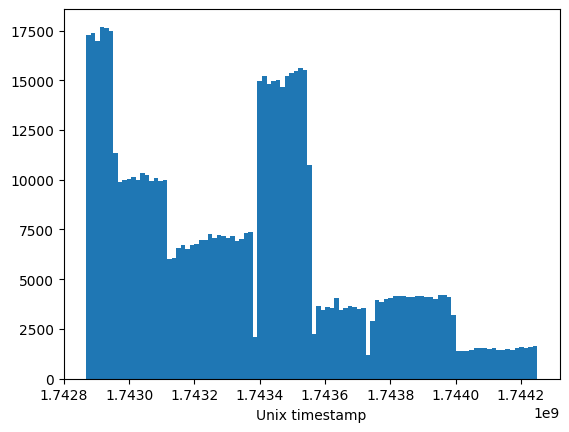

In [189]:
selection = event_all[:,8] < 0
event_selected = event_all[cut_noise & selection ][:,[1,11,7,8,9,10]]
plt.hist( event_selected[:,1], bins = 100 )
plt.xlabel('Unix timestamp')
counter = 0 # counter initialization

data/20250325_NaI_Kamioka/NaI_Background_Bottom_Run0_HV800_20250325_110531.hdf5


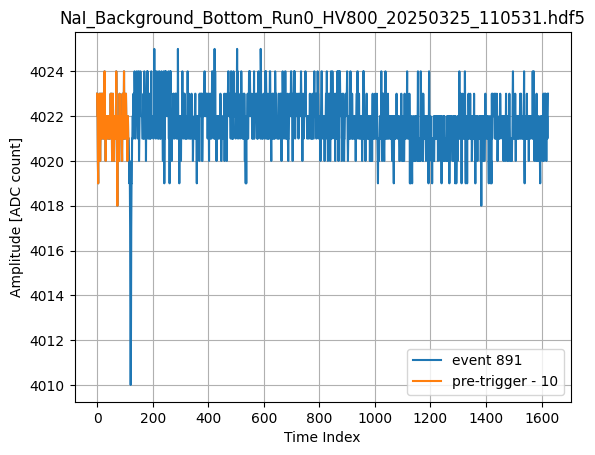

In [117]:
event = event_selected[counter]

filename = find_filename_by_timestamp( event[1], timestamp_list )
print(filename)

plot_waveform( int(event[0]), 0, filename)
counter += 1

## Pile-up Events

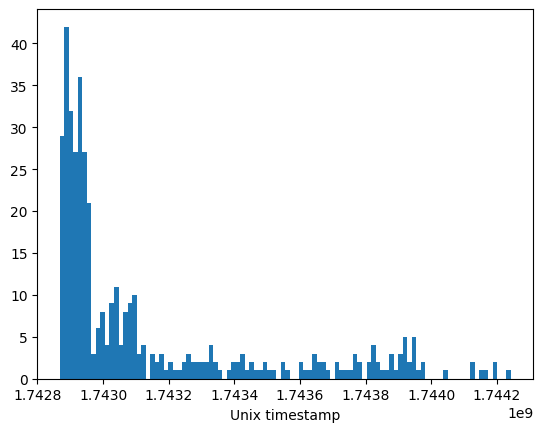

In [190]:
cut_range = (event_all[:,7] > 0) & (event_all[:,7] < 3500)
selection = (Cut_PileUp(event_all[:,7],event_all[:,8]) == False) & cut_range
event_selected = event_all[cut_noise & selection ][:,[1,11,7,8,9,10]]

plt.hist( event_selected[:,1], bins = 100 )
plt.xlabel( 'Unix timestamp' )

counter = 0 # counter initialization

data/20250325_NaI_Kamioka/NaI_Background_Bottom_Run0_HV800_20250325_110531.hdf5


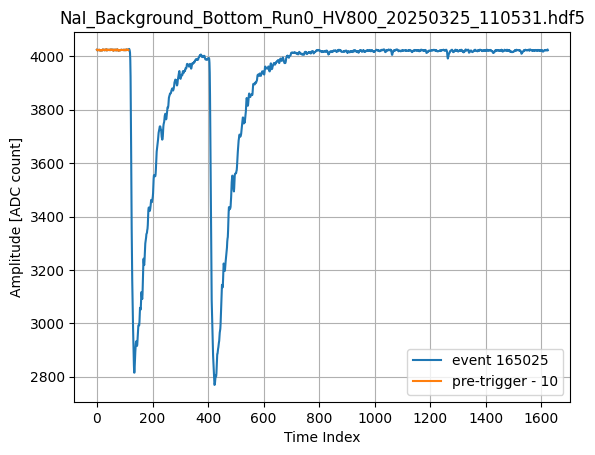

In [195]:
event = event_selected[counter]

filename = find_filename_by_timestamp( event[1], timestamp_list )
print(filename)

plot_waveform( int(event[0]), 0, filename)
counter += 1

## Alpha Events

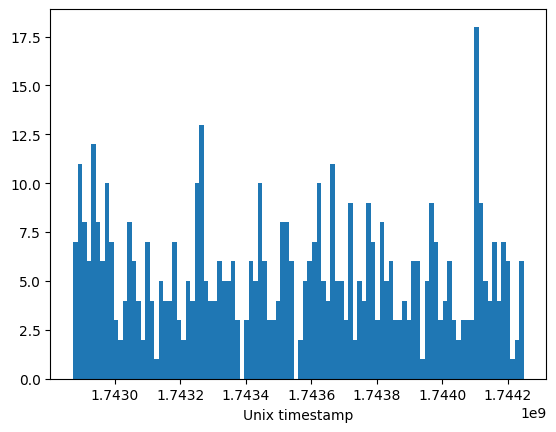

In [196]:
cut_range = (event_all[:,7] > 0) & (event_all[:,7] < 3500)
selection = (Cut_Alpha(event_all[:,7],event_all[:,8]) == False) & (Cut_SPE(event_all[:,7],event_all[:,8]) == True) & cut_range
event_selected = event_all[cut_noise & selection ][:,[1,11,7,8,9,10]]

plt.hist( event_selected[:,1], bins = 100 )
plt.xlabel( 'Unix timestamp' )

counter = 0 # counter initialization

data/20250325_NaI_Kamioka/NaI_Background_Bottom_Run6_HV800_20250325_170959.hdf5


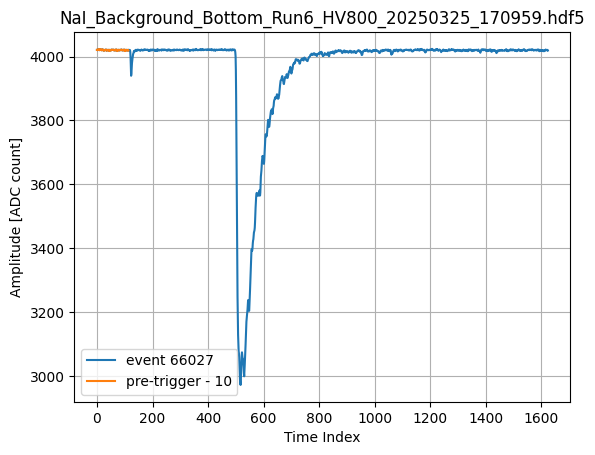

In [209]:
event = event_selected[counter]

filename = find_filename_by_timestamp( event[1], timestamp_list )
print(filename)

plot_waveform( int(event[0]), 0, filename)
counter += 1

## SPE-like Events

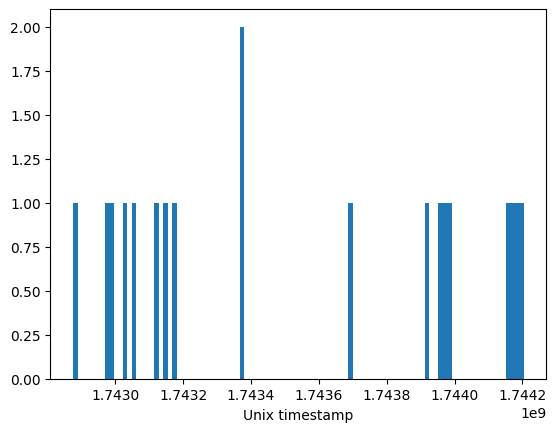

In [258]:
cut_range = (event_all[:,7] > 1000) & (event_all[:,7] < 3500)
selection = (Cut_SPE(event_all[:,7],event_all[:,8]) == False) & cut_range
event_selected = event_all[cut_noise & selection ][:,[1,11,7,8,9,10]]

plt.hist( event_selected[:,1], bins = 100 )
plt.xlabel( 'Unix timestamp' )

counter = 0 # counter initialization

data/20250325_NaI_Kamioka/NaI_Background_East_Run34_HV800_20250403_230633.hdf5


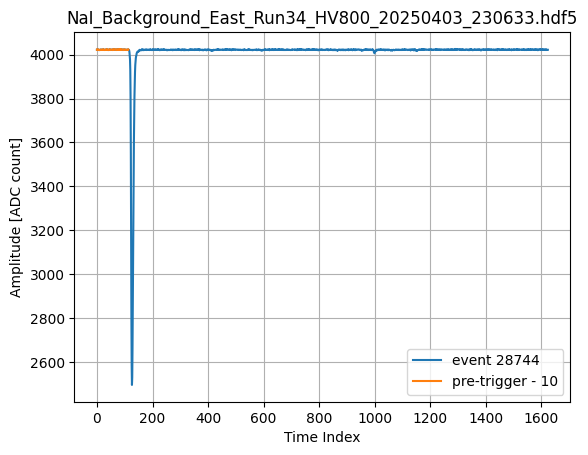

In [261]:
event = event_selected[counter]

filename = find_filename_by_timestamp( event[1], timestamp_list )
print(filename)

plot_waveform( int(event[0]), 0, filename)
counter += 1